<a href="https://colab.research.google.com/github/springboardmentor1/agritield-predictor/blob/Mangesh/Agriyield.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import pandas as pd
import numpy as np
import shap
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Database/dataset.csv')

In [ ]:
print("Dataset Head:\n", df.head())
print("\nDataset Info:\n")
df.info()

Dataset Head:
             State       Crop Soil_Type Fertilizer    N   P    K  Rainfall_mm  \
0       Karnataka    Soybean     Loamy        DAP   96  41   51          123   
1          Odisha     Cotton  Red Soil       Urea   29  36  112          247   
2          Punjab  Groundnut  Red Soil    Compost   37  38  177          142   
3         Gujarat      Wheat  Red Soil    Compost   58  77  129          227   
4  Andhra Pradesh     Cotton      Clay    Organic  108  61   63          263   

   Temperature_C  Yield_kg_per_acre  Soil_pH  Year  
0          31.06               1899     6.82  2003  
1          33.97               1002     6.41  2002  
2          24.21               1465     7.06  2015  
3          30.85               2273     5.93  2022  
4          37.81               1497     6.24  2017  

Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------    

In [ ]:
df = df.dropna()

In [ ]:
categorical_cols = ['State', 'Crop', 'Soil_Type', 'Fertilizer']
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [ ]:
X = df.drop(columns=['Yield_kg_per_acre', 'Year']) # Dropping Year as it's often a sequence index
y = df['Yield_kg_per_acre']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
print("\nPreprocessing Complete.")
print(f"Training set size: {X_train_scaled.shape}")
print(f"Testing set size: {X_test_scaled.shape}")


Preprocessing Complete.
Training set size: (1200, 10)
Testing set size: (300, 10)


In [ ]:
processed_df = pd.DataFrame(X_train_scaled, columns=X.columns)
processed_df['Yield'] = y_train.values
processed_df.to_csv('preprocessed_dataset.csv', index=False)

In [ ]:
sns.set_theme(style="whitegrid")

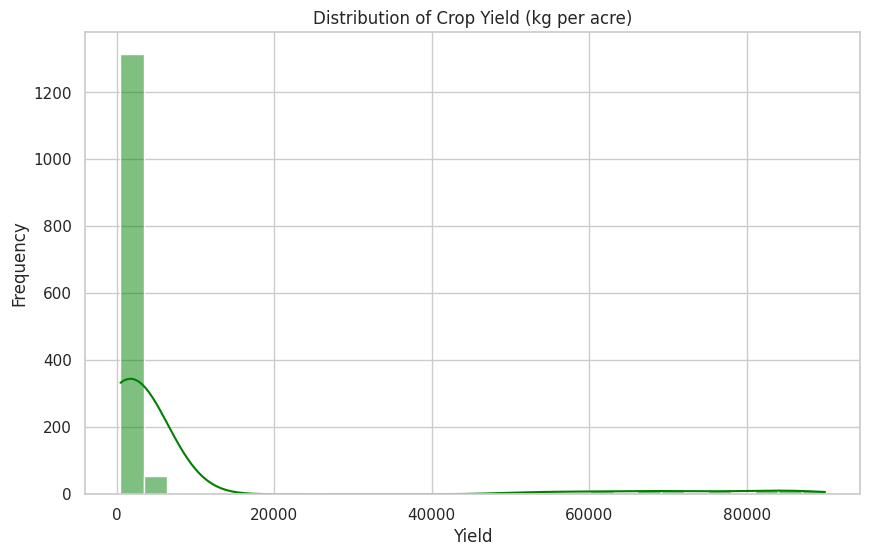

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Yield_kg_per_acre'], kde=True, bins=30, color='green')
plt.title('Distribution of Crop Yield (kg per acre)')
plt.xlabel('Yield')
plt.ylabel('Frequency')
plt.savefig('yield_distribution.png')

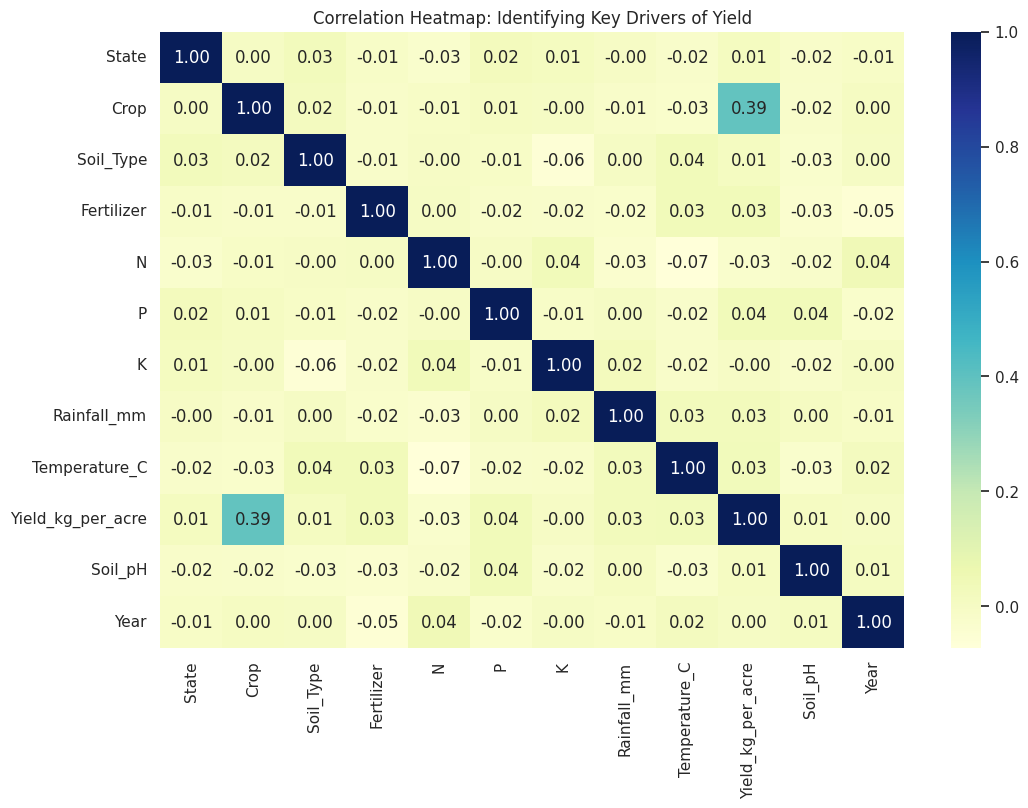

In [ ]:
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Correlation Heatmap: Identifying Key Drivers of Yield')
plt.savefig('correlation_heatmap.png')
plt.show()

/tmp/ipykernel_6645/323803072.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=crop_yield.index, y=crop_yield.values, palette='viridis')


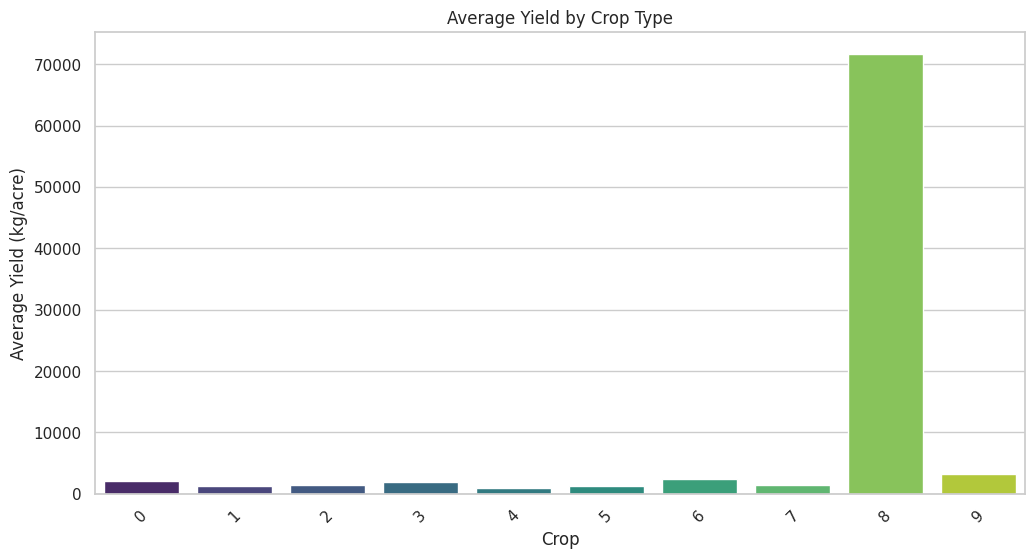

In [ ]:
plt.figure(figsize=(12, 6))
crop_yield = df.groupby('Crop')['Yield_kg_per_acre'].mean().sort_values(ascending=False)
sns.barplot(x=crop_yield.index, y=crop_yield.values, palette='viridis')
plt.title('Average Yield by Crop Type')
plt.xticks(rotation=45)
plt.ylabel('Average Yield (kg/acre)')
plt.savefig('avg_yield_by_crop.png')

/tmp/ipykernel_6645/1525784049.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Soil_Type', y='Yield_kg_per_acre',data=df, palette='Set2')


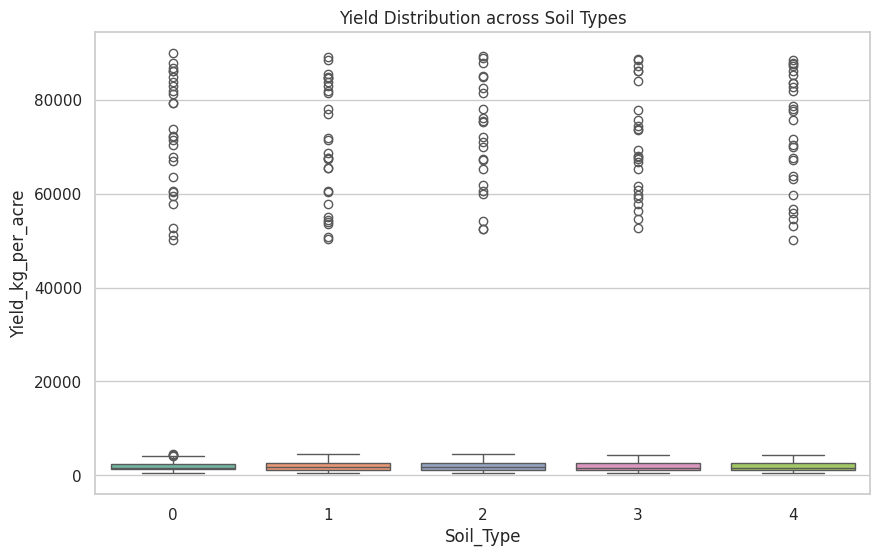

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Soil_Type', y='Yield_kg_per_acre',data=df, palette='Set2')
plt.title('Yield Distribution across Soil Types')
plt.savefig('yield_by_soil.png')

**Milestone 2**

In [ ]:
df['Total_Nutrients'] = df['N'] + df['P'] + df['K']

In [ ]:
df['Temp_Rainfall_Interaction'] = df['Temperature_C'] * df['Rainfall_mm']

In [ ]:
df['Heat_Stress'] = df['Temperature_C'].apply(lambda x: 1 if x > 35 else 0)

In [ ]:
df['pH_Deviation'] = abs(df['Soil_pH'] - 6.5)

In [ ]:
categorical_cols = ['State', 'Crop', 'Soil_Type', 'Fertilizer']
for col in categorical_cols:
    le = LabelEncoder()
    df[col + '_Encoded'] = le.fit_transform(df[col])

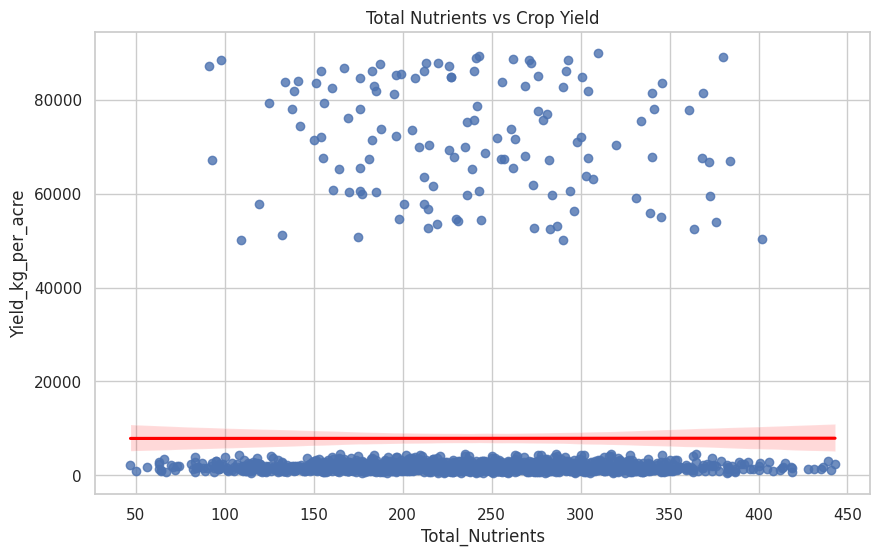

In [ ]:
plt.figure(figsize=(10, 6))
sns.regplot(x='Total_Nutrients', y='Yield_kg_per_acre', data=df,
            scatter_kws={'alpha':0.8}, line_kws={'color':'red'})
plt.title('Total Nutrients vs Crop Yield')
plt.savefig('nutrients_vs_yield.png')

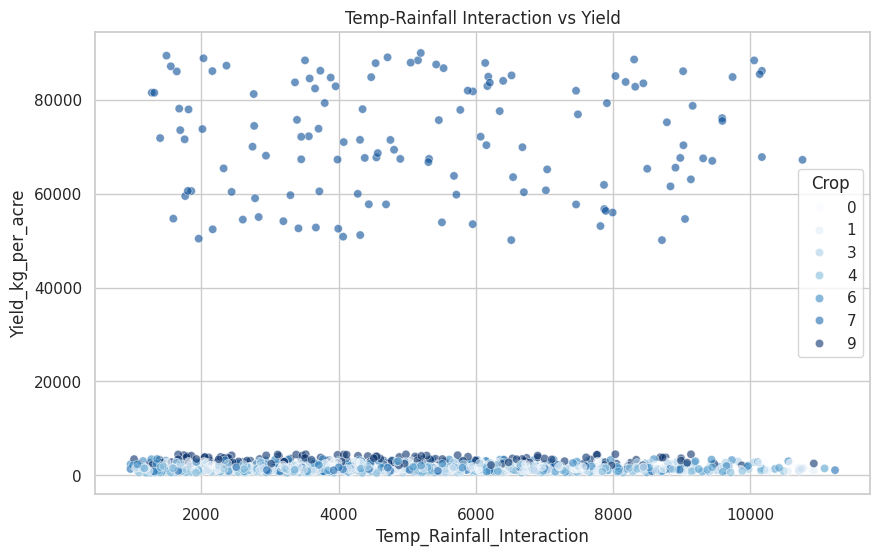

In [ ]:

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Temp_Rainfall_Interaction', y='Yield_kg_per_acre',
                hue='Crop', data=df, palette='Blues', alpha=0.6)
plt.title('Temp-Rainfall Interaction vs Yield')
plt.savefig('interaction_vs_yield.png')

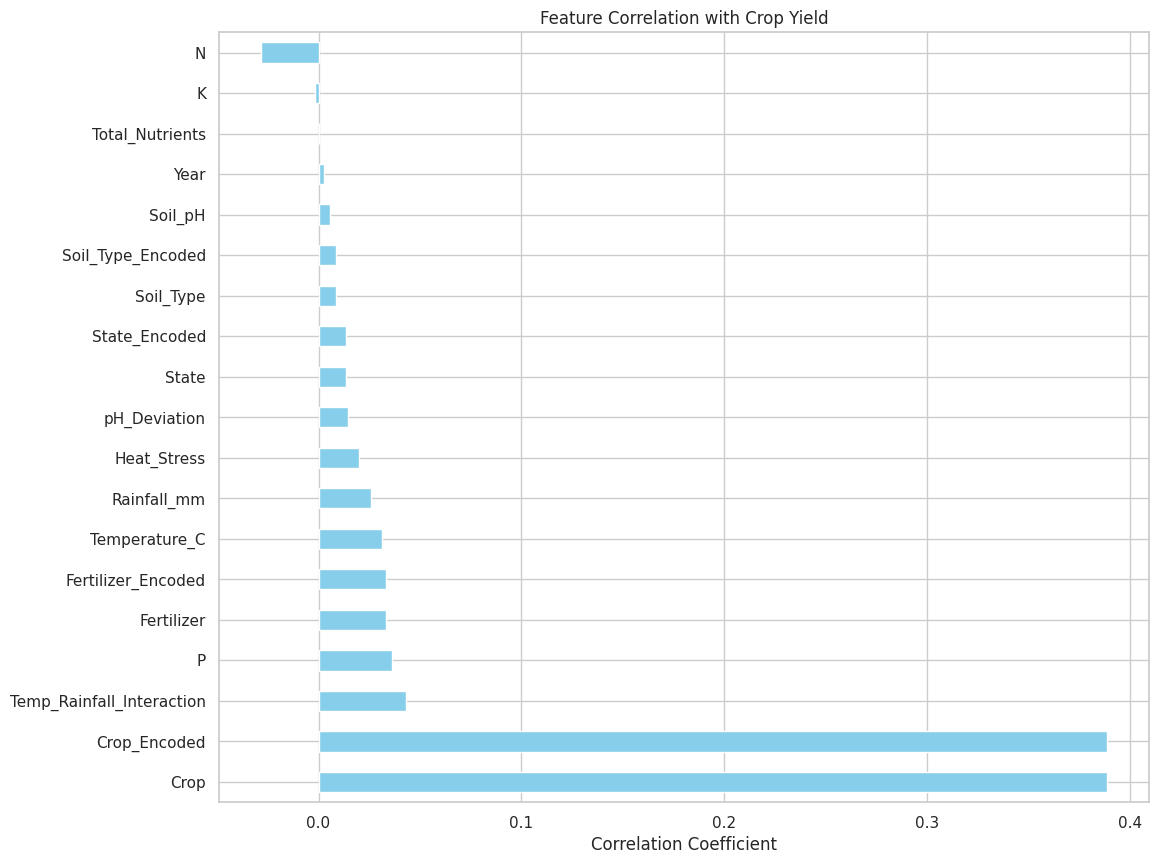

In [ ]:
plt.figure(figsize=(12, 10))
numeric_df = df.select_dtypes(include=[np.number])
correlations = numeric_df.corr()['Yield_kg_per_acre'].sort_values(ascending=False)
correlations.drop('Yield_kg_per_acre').plot(kind='barh', color='skyblue')
plt.title('Feature Correlation with Crop Yield')
plt.xlabel('Correlation Coefficient')
plt.savefig('feature_importance_correlation.png')

In [ ]:
df.to_csv('engineered_dataset.csv', index=False)

In [ ]:
df = pd.read_csv("engineered_dataset.csv")

# Check data
print(df.shape)
print(df.head())

(1500, 20)
   State  Crop  Soil_Type  Fertilizer    N   P    K  Rainfall_mm  \
0      4     7          2           1   96  41   51          123   
1      8     1          3           5   29  36  112          247   
2      9     2          3           0   37  38  177          142   
3      2     9          3           0   58  77  129          227   
4      0     1          1           3  108  61   63          263   

   Temperature_C  Yield_kg_per_acre  Soil_pH  Year  Total_Nutrients  \
0          31.06               1899     6.82  2003              188   
1          33.97               1002     6.41  2002              177   
2          24.21               1465     7.06  2015              252   
3          30.85               2273     5.93  2022              264   
4          37.81               1497     6.24  2017              232   

   Temp_Rainfall_Interaction  Heat_Stress  pH_Deviation  State_Encoded  \
0                    3820.38            0          0.32              4   
1    

In [ ]:
X = df.drop("Yield_kg_per_acre", axis=1)
y = df["Yield_kg_per_acre"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [ ]:
scaler = StandardScaler()

num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

In [ ]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

In [ ]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [ ]:
xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

In [ ]:
def evaluate_model(name, y_test, pred):
    print(f"\n{name} Results")
    print("R2:", r2_score(y_test, pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))  # FIXED
    print("MAE:", mean_absolute_error(y_test, pred))

In [ ]:
evaluate_model("Linear Regression", y_test, lr_pred)
evaluate_model("Random Forest", y_test, rf_pred)
evaluate_model("XGBoost", y_test, xgb_pred)


Linear Regression Results
R2: 0.060299519734321905
RMSE: 17519.10035889299
MAE: 11414.368979385377

Random Forest Results
R2: 0.978380921191686
RMSE: 2657.2699019194806
MAE: 939.0992333333332

XGBoost Results
R2: 0.9763620495796204
RMSE: 2778.5738248245266
MAE: 1025.3494873046875


In [ ]:
rf_importance = pd.Series(rf.feature_importances_, index=X.columns)

print("\nTop Features (Random Forest):")
print(rf_importance.sort_values(ascending=False).head(10))


Top Features (Random Forest):
Crop_Encoded                 0.507777
Crop                         0.459708
Temperature_C                0.003830
Year                         0.003675
P                            0.003429
pH_Deviation                 0.003099
N                            0.002857
Temp_Rainfall_Interaction    0.002506
K                            0.002427
Rainfall_mm                  0.002260
dtype: float64


In [ ]:
xgb_importance = pd.Series(xgb.feature_importances_, index=X.columns)

print("\nTop Features (XGBoost):")
print(xgb_importance.sort_values(ascending=False).head(10))


Top Features (XGBoost):
Crop                         0.951871
pH_Deviation                 0.006382
Rainfall_mm                  0.005211
Temp_Rainfall_Interaction    0.004811
Year                         0.004676
Temperature_C                0.003865
Total_Nutrients              0.003654
N                            0.003650
K                            0.003591
Fertilizer                   0.003524
dtype: float32


In [ ]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "XGBoost"],
    "R2": [
        r2_score(y_test, lr_pred),
        r2_score(y_test, rf_pred),
        r2_score(y_test, xgb_pred)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, lr_pred)),
        np.sqrt(mean_squared_error(y_test, rf_pred)),
        np.sqrt(mean_squared_error(y_test, xgb_pred))
    ],
    "MAE": [
        mean_absolute_error(y_test, lr_pred),
        mean_absolute_error(y_test, rf_pred),
        mean_absolute_error(y_test, xgb_pred)
    ]
})

print("\nModel Comparison:")
print(results)


Model Comparison:
               Model        R2          RMSE           MAE
0  Linear Regression  0.060300  17519.100359  11414.368979
1      Random Forest  0.978381   2657.269902    939.099233
2            XGBoost  0.976362   2778.573825   1025.349487


In [ ]:
best_model = results.sort_values(by="R2", ascending=False).iloc[0]
print("\nBest Model:")
print(best_model)


Best Model:
Model    Random Forest
R2            0.978381
RMSE       2657.269902
MAE         939.099233
Name: 1, dtype: object
